# Optimal Transport in linear Independent Component Analysis
### Simulated Experiment: Double IC extraction with squared Wasserstein Distance - Continous - Laplace and Student-t

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import scipy.stats

from wasserstein_ica import WassersteinICA

In [2]:
# --- 1. Simulation Setup ---
n_samples = 5000
np.random.seed(42)

# Source 1: Student-t distribution with df=2 (Infinite Variance)
# Note: df=2 implies infinite variance, which challenges standard whitening.
s1 = np.random.standard_t(df=3, size=n_samples)

# Source 2: Laplace distribution
s2 = np.random.laplace(loc=0.0, scale=1.0/np.sqrt(2), size=n_samples)

# Stack and Mix
S_true = np.stack([s1, s2])
A_true = np.array([[1.0, 0.5], 
                   [0.5, 1.0]])  # Mixing matrix
X_mixed = A_true @ S_true

# Convert to Torch for WassersteinICA
X_torch = torch.tensor(X_mixed, dtype=torch.float32)

In [3]:
# --- 2. Initialization & Whitening ---
ica = WassersteinICA(X_torch)
ica.whiten()

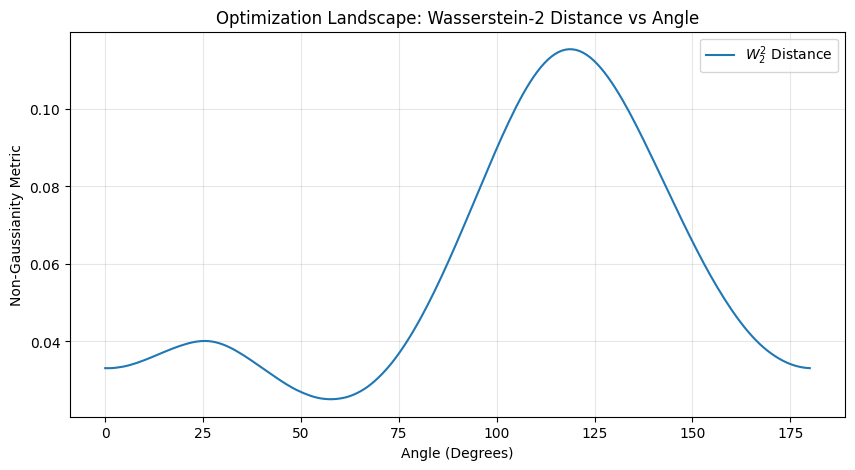

In [4]:
# --- 3. Landscape Visualization (Plotting best candidates) ---
# We manually scan angles to plot the W2^2 metric landscape before extraction
angles = torch.linspace(0, np.pi, steps=200)
candidates = torch.stack([torch.cos(angles), torch.sin(angles)], dim=1).to(X_torch.device)
distances = []

for w in candidates:
    # Compute score for each angle
    dist = ica.wasserstein2_distance(w)
    distances.append(dist.item())

plt.figure(figsize=(10, 5))
plt.plot(np.degrees(angles.numpy()), distances, label=r'$W_2^2$ Distance')
plt.title("Optimization Landscape: Wasserstein-2 Distance vs Angle")
plt.xlabel("Angle (Degrees)")
plt.ylabel("Non-Gaussianity Metric")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [5]:
# --- 4. Sequential Extraction ---
print("\n--- Extracting Components ---")

# Extract 1st Component
# We use continuous optimization for precision
w1, dist1 = ica.optimize_wasserstein2(continuous=True, grid_points=100)
print(f"1st Component found. Score: {dist1:.4f}")

# Extract 2nd Component (Orthogonal to 1st)
# We pass w1 to 'prev_components' to force orthogonality
w2, dist2 = ica.optimize_wasserstein2(prev_components=w1.unsqueeze(0), continuous=True)
print(f"2nd Component found. Score: {dist2:.4f}")

# Project whitened data onto weights to get estimates
# Shape: (2, n_samples)
Y_est = torch.stack([
    torch.mv(ica.X_white.t(), w1),
    torch.mv(ica.X_white.t(), w2)
]).numpy()


--- Extracting Components ---
1st Component found. Score: 0.0401
2nd Component found. Score: 0.1148


In [6]:
# --- 5. KL Divergence Evaluation ---

def compute_kl_divergence(p_samples, q_samples, bins=100):
    """
    Computes KL(P || Q) using histograms. 
    P: True Source, Q: Extracted Component
    """
    # Normalize samples to roughly same scale (Z-score) to handle scaling ambiguity
    # KL is sensitive to support mismatch, so we look at shape only.
    p_norm = (p_samples - np.mean(p_samples)) / np.std(p_samples)
    q_norm = (q_samples - np.mean(q_samples)) / np.std(q_samples)
    
    # Define common range
    min_val = min(p_norm.min(), q_norm.min())
    max_val = max(p_norm.max(), q_norm.max())
    
    # Compute histograms
    p_hist, edges = np.histogram(p_norm, bins=bins, range=(min_val, max_val), density=True)
    q_hist, _ = np.histogram(q_norm, bins=bins, range=(min_val, max_val), density=True)
    
    # Add epsilon to avoid log(0) or div by 0
    epsilon = 1e-10
    p_hist = p_hist + epsilon
    q_hist = q_hist + epsilon
    
    # Normalize again to ensure sum=1
    p_hist /= p_hist.sum()
    q_hist /= q_hist.sum()
    
    return scipy.stats.entropy(p_hist, q_hist)

In [7]:
print("\n--- KL Divergences (Original vs Extracted) ---")
sources_names = ["Student-t (df=2)", "Laplace"]
extracted_names = ["Extracted IC 1", "Extracted IC 2"]

# Calculate all 4 pairs
kl_matrix = np.zeros((2, 2))
for i in range(2):
    for j in range(2):
        kl = compute_kl_divergence(S_true[i], Y_est[j])
        kl_matrix[i, j] = kl
        print(f"KL({sources_names[i]} || {extracted_names[j]}) = {kl:.4f}")

# Identify best match permutation based on lowest KL sum
if kl_matrix[0,0] + kl_matrix[1,1] < kl_matrix[0,1] + kl_matrix[1,0]:
    print("\nLikely alignment: S1 -> E1, S2 -> E2")
else:
    print("\nLikely alignment: S1 -> E2, S2 -> E1")


--- KL Divergences (Original vs Extracted) ---
KL(Student-t (df=2) || Extracted IC 1) = 0.0772
KL(Student-t (df=2) || Extracted IC 2) = 0.0379
KL(Laplace || Extracted IC 1) = 0.0584
KL(Laplace || Extracted IC 2) = 0.0409

Likely alignment: S1 -> E2, S2 -> E1


In [8]:
# Since ICA output order is arbitrary, we match Y to S using correlation
corr_matrix = np.abs(np.corrcoef(np.vstack([S_true, Y_est])))
cross_corr = corr_matrix[0:2, 2:4] # Top-right block: Rows S1,S2 vs Cols Y1,Y2

# Determine permutation
if cross_corr[0,0] + cross_corr[1,1] > cross_corr[0,1] + cross_corr[1,0]:
    perm = [0, 1] # S1->Y1, S2->Y2
    print("Matched: S1 -> Y1, S2 -> Y2")
else:
    perm = [1, 0] # S1->Y2, S2->Y1
    print("Matched: S1 -> Y2, S2 -> Y1")

Y_aligned = Y_est[perm, :]

# Fix Sign Ambiguity
# If correlation is negative, flip the extracted signal
if np.corrcoef(s1, Y_aligned[0])[0,1] < 0:
    Y_aligned[0] *= -1
if np.corrcoef(s2, Y_aligned[1])[0,1] < 0:
    Y_aligned[1] *= -1

Matched: S1 -> Y2, S2 -> Y1


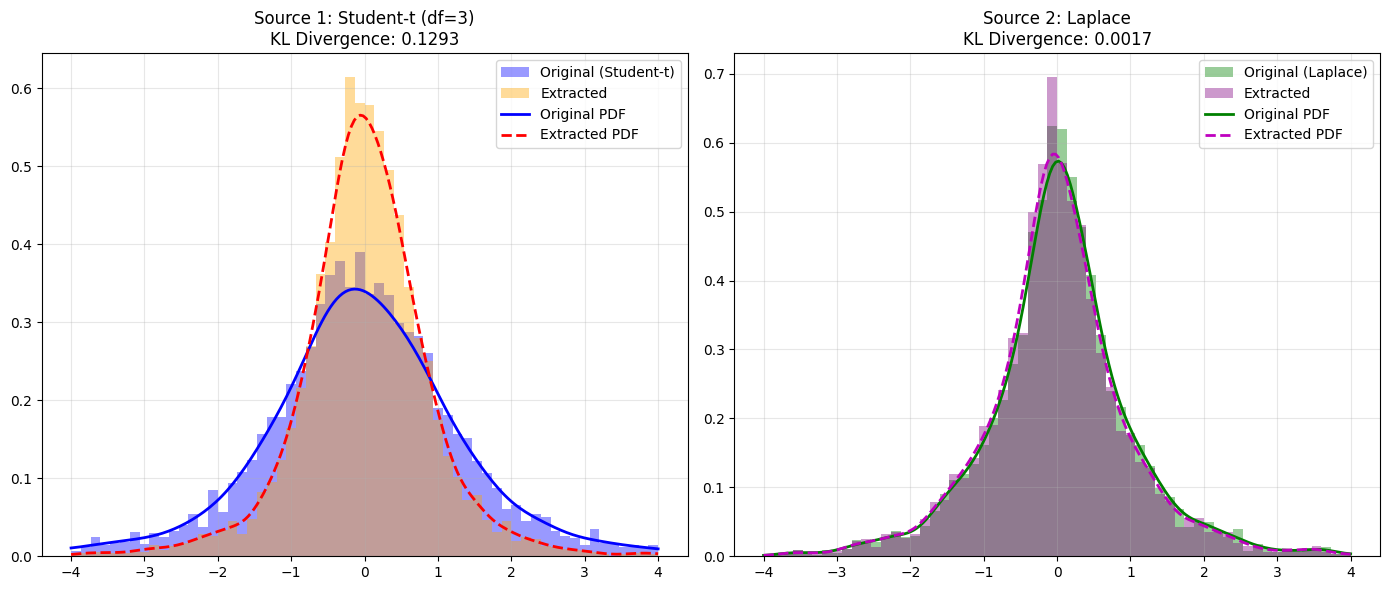

In [9]:
# --- 4. Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Define plotting parameters
bins = 60
range_lim = (-4, 4)
x_grid = np.linspace(range_lim[0], range_lim[1], 200)

# Plot 1: Student-t Comparison
axes[0].hist(s1, bins=bins, range=range_lim, density=True, alpha=0.4, label='Original (Student-t)', color='blue')
axes[0].hist(Y_aligned[0], bins=bins, range=range_lim, density=True, alpha=0.4, label='Extracted', color='orange')
# KDE Overlays
kde_s1 = scipy.stats.gaussian_kde(s1)
kde_y1 = scipy.stats.gaussian_kde(Y_aligned[0])
axes[0].plot(x_grid, kde_s1(x_grid), 'b-', lw=2, label='Original PDF')
axes[0].plot(x_grid, kde_y1(x_grid), 'r--', lw=2, label='Extracted PDF')
axes[0].set_title(f'Source 1: Student-t (df=3)\nKL Divergence: {scipy.stats.entropy(kde_s1(x_grid), kde_y1(x_grid)):.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Laplace Comparison
axes[1].hist(s2, bins=bins, range=range_lim, density=True, alpha=0.4, label='Original (Laplace)', color='green')
axes[1].hist(Y_aligned[1], bins=bins, range=range_lim, density=True, alpha=0.4, label='Extracted', color='purple')
# KDE Overlays
kde_s2 = scipy.stats.gaussian_kde(s2)
kde_y2 = scipy.stats.gaussian_kde(Y_aligned[1])
axes[1].plot(x_grid, kde_s2(x_grid), 'g-', lw=2, label='Original PDF')
axes[1].plot(x_grid, kde_y2(x_grid), 'm--', lw=2, label='Extracted PDF')
axes[1].set_title(f'Source 2: Laplace\nKL Divergence: {scipy.stats.entropy(kde_s2(x_grid), kde_y2(x_grid)):.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()